In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')


df_train = pd.read_csv('/content/drive/MyDrive/ml projekt/train_clean.csv')
#print(df_train.head)
#print(df_train.info)

# Podział danych na cechy i etykiety
X = df_train['clean_lemma']
y = df_train['label']

Mounted at /content/drive


In [ ]:

X = X.fillna('')
vectorizer = TfidfVectorizer(max_features=5000)
X_vectorized = vectorizer.fit_transform(X)

In [ ]:
# Podział danych na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.2, random_state=42)

In [ ]:
# Inicjalizacja i trenowanie modelu
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("--- Logistic Regression ---")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

--- Logistic Regression ---
Accuracy: 0.9493311152699799
Precision: 0.9482969195277514
Recall: 0.952303079858272
F1 Score: 0.9502957775209084


--- Trenowanie modelu: Logistic Regression ---
Wyniki dla modelu Logistic Regression:
Accuracy: 0.9493
Precision: 0.9483
Recall: 0.9523
F1 Score: 0.9503


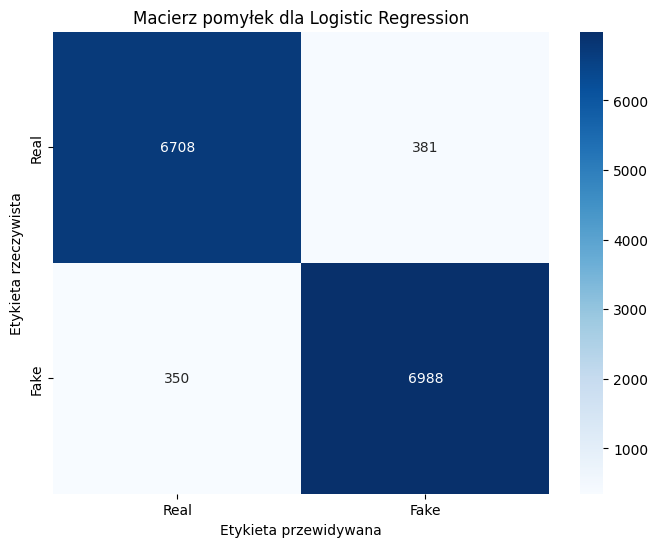


----------------------------------------

--- Trenowanie modelu: Random Forest Classifier ---
Wyniki dla modelu Random Forest Classifier:
Accuracy: 0.9616
Precision: 0.9576
Recall: 0.9673
F1 Score: 0.9624


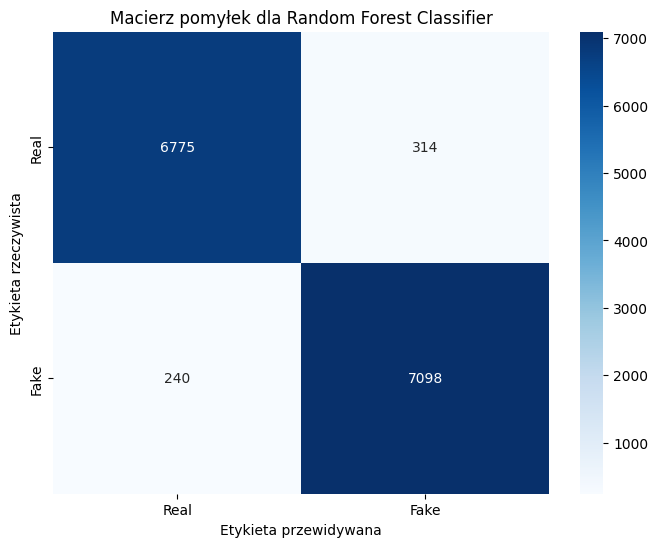


----------------------------------------

--- Trenowanie modelu: SVM ---
Wyniki dla modelu SVM:
Accuracy: 0.9568
Precision: 0.9545
Recall: 0.9609
F1 Score: 0.9577


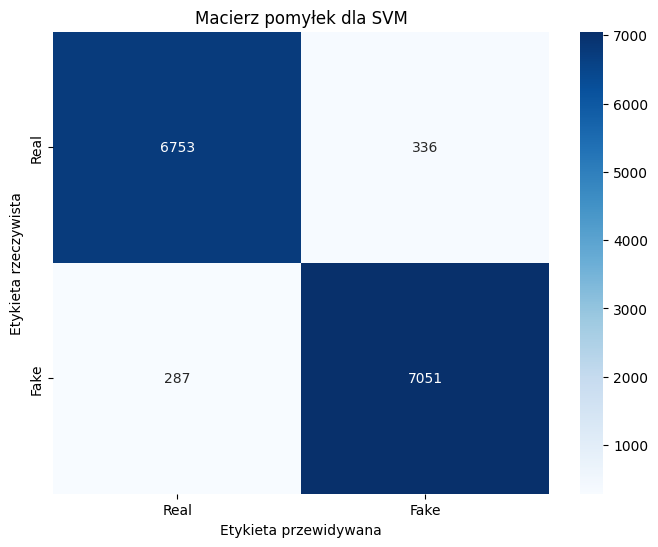


----------------------------------------



In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest Classifier": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='linear', random_state=42)
}

# Trenowanie i ocena każdego z modeli
for name, model in models.items():
    print(f"--- Trenowanie modelu: {name} ---")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Wyświetlanie metryk
    print(f"Wyniki dla modelu {name}:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")

    # Tworzenie i wyświetlanie macierzy pomyłek
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
    plt.xlabel('Etykieta przewidywana')
    plt.ylabel('Etykieta rzeczywista')
    plt.title(f'Macierz pomyłek dla {name}')
    plt.show()

    print("\n" + "-"*40 + "\n")


# **Wnioski:**

1.   Logistic Regression osiągnał donry wynik z wyoksą dokładnością, lecz w porówaniu do pozostałych modeli to słabo wypada
2.   Random Forest Classifier, model ten ma najwyższą dokładność. Wyróżnia się również najlepszym wynikiem Recall (0.9673), co oznacza, że jest najbardziej efektywny w wykrywaniu wszystkich fałszywych wiadomości i minimalizuje liczbę przeoczeń
3. SVM (Support Vector Machine) Model SVM wykazuje bardzo zrównoważoną wydajność.






# **Porównanie modeli ML a Deep Learning**

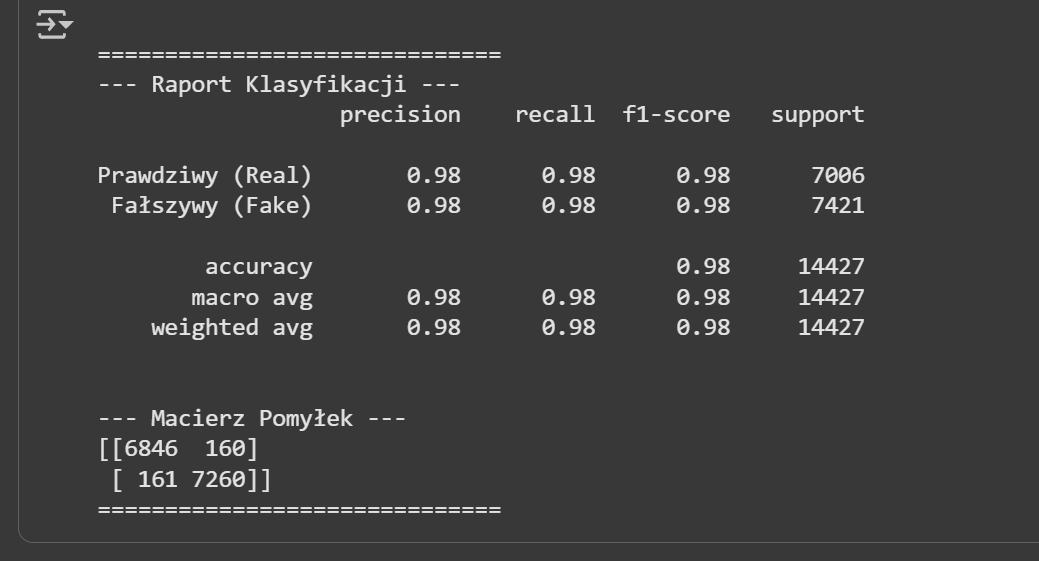

(Dane do Deep Learningu są od Pawła)

In [1]:
import io
import pandas as pd
pd.read_csv(io.StringIO('''
Model,Accuracy,Precision,Recall,F1 Score,"Błędnie jako ""Fake"""
Bi-LSTM (DL),0.980,0.980,0.980,0.980,160
Random Forest,0.962,0.958,0.967,0.962,314
SVM,0.957,0.955,0.961,0.958,336
Logistic Regression,0.949,0.948,0.952,0.950,381
'''), header=None)


,0,1,2,3,4,5
0,Model,Accuracy,Precision,Recall,F1 Score,"Błędnie jako ""Fake"""
1,Bi-LSTM (DL),0.980,0.980,0.980,0.980,160
2,Random Forest,0.962,0.958,0.967,0.962,314
3,SVM,0.957,0.955,0.961,0.958,336
4,Logistic Regression,0.949,0.948,0.952,0.950,381


#**Analiza Metryk**




*  Accuracy (Dokładność): Model Bi-LSTM osiągnął na zbiorze walidacyjnym dokładność na poziomie 98%, oznacza to, że 98% wszystkich wiadomośc, zostało poprawnie sklasyfikowanych. Jest to najwyższy wynik spośród wszystkich zaimplementowanych modeli, w tym klasycznych
*  F1 Score: Model osiągnął F1 Score na poziomie 98%, co jest potwierdzeniem bardzo dobrego zrównoważenia precyzji i czułości. Jest to metryka, która daje najbardziej kompleksowy obraz wydajności.
* To zbalansowanie metryk świadczy o tym, że model jest wiarygodny i bezstronny. Jest równie skuteczny w wykrywaniu fake newsów (wysoki Recall), jak i w poprawnym oznaczaniu prawdziwych wiadomości (wysoka Precision



# **Wnioski:**
Implementacja modeli klasycznych była doskonałym punktem odniesienia, który pokazał, że nawet podstawowe algorytmy radzą sobie bardzo dobrze z zadaniem wykrywania fake newsów. Jednakże, ostateczne porównanie wyraźnie wskazuje na przewagę modelu Deep Learning.

Model Bi-LSTM okazał się najbardziej precyzyjny, niezawodny i skuteczny w minimalizacji błędów, które niosą ze sobą największe ryzyko. Dzięki zaawansowanej architekturze, która potrafi analizować kontekst i semantykę tekstu, Bi-LSTM jest w stanie lepiej odróżniać fałszywe wiadomości od prawdziwych.

